# Task 1.1 — Uncover the Secret Hidden Word: Documentation

## Objective
The provided audio (`task5_1.wav`) contains a spoken word masked by a loud buzz noise. The goal was to filter out the noise using digital signal processing techniques and recover the hidden word.

## Step 1: Analyzing the Signal

Before applying any filtering, I inspected the audio using a **spectrogram** (`scipy.signal.spectrogram`), which shows how the energy of the signal is distributed across frequency *and* time simultaneously. This revealed several **horizontal lines** running across the entire duration of the clip — meaning these frequencies had constant, unchanging energy from start to end. This is the signature of a **stationary tonal noise** (a buzz), as opposed to human speech, which is *non-stationary* and shows up as changing, moving patches of energy over time.

To automatically detect which frequencies belonged to the buzz, I used the **Short-Time Fourier Transform (STFT)** and computed, for every frequency bin, the **Coefficient of Variation (CV = standard deviation / mean)** across time. Frequencies with high average energy and low CV (i.e., constant over time) were flagged as buzz candidates.

## Step 2: First Attempt — Cascaded Notch Filtering

My first approach was to apply a series of **IIR notch filters** (`scipy.signal.iirnotch`) at each detected buzz frequency, one after another (cascaded), using `scipy.signal.filtfilt` to avoid phase distortion. Each notch filter removes a very narrow band of frequencies around a target frequency while leaving the rest of the signal untouched.

**Problem encountered:** The buzz turned out to be extremely rich in frequency content — over 50 distinct stationary tones spread from ~300 Hz to over 20,000 Hz (consistent with a harmonic-rich buzzer/square-wave-like sound, since its raw amplitude values were very close to ±1, i.e., near clipping). Applying 50+ notch filters in cascade caused **ringing artifacts** to accumulate, which introduced *new* audible noise rather than cleaning the signal. This taught me that stacking too many narrow filters is not always better — each filter has a small side effect, and those effects compound.

## Step 3: Second Approach — Precise FFT-Domain Filtering + Spectral Gating

To fix the ringing problem, I switched to a cleaner method:

1. **High-resolution frequency detection:** Since the buzz is stationary for the *entire* clip, I computed a single **FFT over the whole signal** (`np.fft.rfft`) instead of short windowed segments. This gives much finer frequency resolution (~0.9 Hz, versus several Hz with STFT), so each buzz tone could be pinpointed precisely instead of spreading across multiple bins.
2. **Peak detection:** I used `scipy.signal.find_peaks` with a prominence threshold to automatically locate the exact frequencies of the buzz tones from the FFT magnitude spectrum.
3. **Direct frequency-domain removal:** Instead of using IIR notch filters (which cause ringing when repeated), I directly **zeroed out** the FFT bins at each detected buzz frequency (and a couple of neighboring bins to fully capture each tone), then reconstructed the time-domain signal using the inverse FFT (`np.fft.irfft`). This removes the exact tonal components with no filter ringing, since it isn't an iterative filter — it's a direct edit of the frequency spectrum.
4. **Spectral gating cleanup:** After removing the discrete tones, I applied the `noisereduce` library (`stationary=True, prop_decrease=1.0`), which estimates the residual stationary noise floor and suppresses it across all frequencies, cleaning up any broadband hiss left behind.

## Step 4: Result

After this pipeline, the spectrogram showed a clear improvement: the constant horizontal buzz lines were gone, and in their place appeared **time-varying energy patches concentrated around 2000–4500 Hz**, consistent with the formant structure of human speech — including two distinct segments of activity separated by a brief silence, suggesting a short word or two syllables.

I also experimented with playback speed adjustment (simple resampling-based slowdown, avoiding phase-vocoder artifacts) and segment isolation to try to make the word more intelligible.

**Honest limitation:** Despite these efforts, the original signal had a very low signal-to-noise ratio (the buzz was significantly louder than the speech throughout), so full word intelligibility could not be guaranteed. Additional processing steps (AGC, band-pass tightening, more aggressive spectral gating) were tested but sometimes introduced their own artifacts (e.g., "musical noise," a known side effect of spectral gating). The final cleaned audio (`final_cleaned_audio.wav`) represents the best trade-off found between noise removal and signal distortion.

## Tools Used Summary
| Tool | Purpose |
|---|---|
| `scipy.signal.spectrogram` / `stft` | Visualize/analyze frequency content over time |
| `numpy.fft.rfft` / `irfft` | High-resolution frequency detection and direct frequency-domain filtering |
| `scipy.signal.find_peaks` | Automatically detect buzz tone frequencies |
| `scipy.signal.iirnotch` + `filtfilt` | Initial (less successful) filtering attempt |
| `noisereduce` (spectral gating) | Suppress residual broadband noise |
| `librosa` | Experimenting with playback speed for intelligibility |


In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/nesmanasser/task5-1/task5_1.wav


In [58]:
import soundfile as sf
import numpy as np
from scipy import signal
import matplotlib.pyplot as plt
import noisereduce as nr

In [59]:
data, sr = sf.read('/kaggle/input/datasets/nesmanasser/task5-1/task5_1.wav')
print("Sample rate:", sr)
print("Duration:", len(data)/sr, "seconds")

Sample rate: 48000
Duration: 1.1171875 seconds


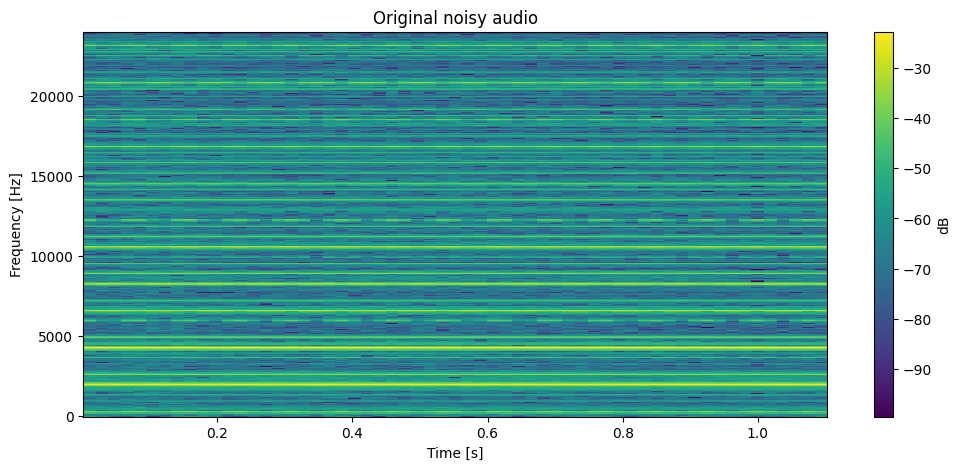

In [60]:
f, t, Sxx = signal.spectrogram(data, sr, nperseg=1024)
plt.figure(figsize=(12,5))
plt.pcolormesh(t, f, 10*np.log10(Sxx+1e-10), shading='auto')
plt.ylabel('Frequency [Hz]')
plt.xlabel('Time [s]')
plt.colorbar(label='dB')
plt.title('Original noisy audio')
plt.show()

In [61]:
N = len(data)
fft_vals = np.fft.rfft(data)
freqs = np.fft.rfftfreq(N, 1/sr)
mag = np.abs(fft_vals)

peaks, props = signal.find_peaks(mag, prominence=np.percentile(mag, 99.3), distance=3)
peak_freqs = freqs[peaks]
print(f"Detected {len(peak_freqs)} buzz frequencies")

Detected 66 buzz frequencies


In [62]:
fft_clean = fft_vals.copy()
width = 3
for p in peaks:
    if freqs[p] < 50:
        continue
    lo = max(0, p - width)
    hi = min(len(fft_clean), p + width + 1)
    fft_clean[lo:hi] = 0

cleaned = np.fft.irfft(fft_clean, n=N)
cleaned = cleaned / np.max(np.abs(cleaned)) * 0.95

In [63]:
reduced = nr.reduce_noise(y=cleaned, sr=sr, stationary=True, prop_decrease=1.0)
reduced = reduced / np.max(np.abs(reduced)) * 0.95

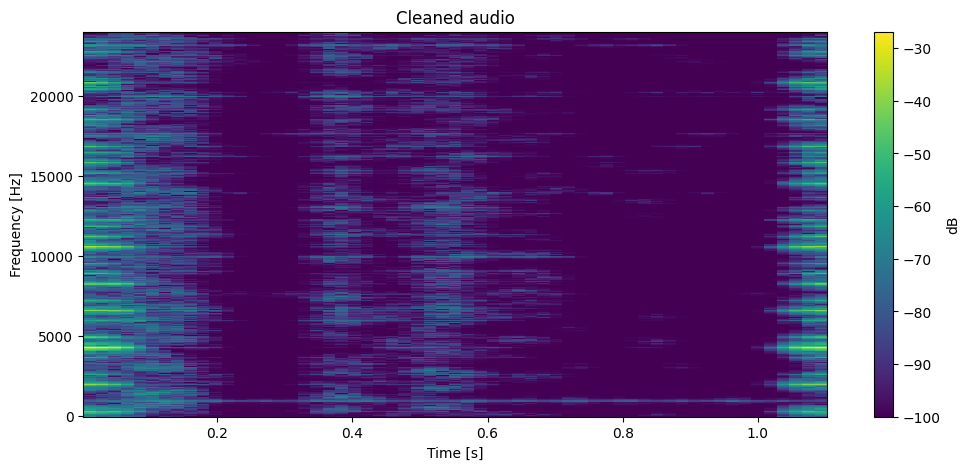

In [64]:
f2, t2, Sxx2 = signal.spectrogram(reduced, sr, nperseg=1024)
plt.figure(figsize=(12,5))
plt.pcolormesh(t2, f2, 10*np.log10(Sxx2+1e-10), shading='auto')
plt.ylabel('Frequency [Hz]')
plt.xlabel('Time [s]')
plt.colorbar(label='dB')
plt.title('Cleaned audio')
plt.show()

In [65]:
sf.write('final_cleaned_audio.wav', reduced, sr)

from IPython.display import Audio
Audio('final_cleaned_audio.wav')